In [ ]:
import os

def delete_small_logs(folder_path: str):
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as f:
                lines = f.readlines()
                if len(lines) < 20:
                    os.remove(file_path)
                    print(f'Deleted {file_path}')
folder_path = 'YOUR_FOLDER_PATH_HERE' # 替换为您的文件夹路径
delete_small_logs(folder_path)

In [60]:
import sys
import torch
import os
import math
import torch.nn as nn
import pandas as pd
import numpy as np
from PIL import Image
from torchvision import transforms
# a = [i for i in range(224*224*3)]
# a = np.array(a).reshape((224,224,3))
a = [i for i in range(100*100)]
a = np.array(a).reshape((100,100,1))*np.array([[[1,1,1]]])
print((a[0:3,0:3,:]))
a = Image.fromarray(np.array(a,dtype=np.uint8))
a.show()
print((np.array(a.crop((0, 0,3,3)))))
#Image库数据溢出了

[[[  0   0   0]
  [  1   1   1]
  [  2   2   2]]

 [[100 100 100]
  [101 101 101]
  [102 102 102]]

 [[200 200 200]
  [201 201 201]
  [202 202 202]]]
[[[  0   0   0]
  [  1   1   1]
  [  2   2   2]]

 [[100 100 100]
  [101 101 101]
  [102 102 102]]

 [[200 200 200]
  [201 201 201]
  [202 202 202]]]


In [3]:
# !pip install timm --target=c:\users\admin\anac
# !pip list
import torch
import numpy as np
from Dataset.Dataset_swin import mymodel
from models import InternImage

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

pretrained = r'/home/guwei/GW-main/SVM/checkpoint/intern_200.pth'
model = InternImage(
        core_op='DCNv3',
        channels=112,
        depths=[4, 4, 21, 4],
        groups=[7, 14, 28, 56],
        mlp_ratio=4.,
        drop_path_rate=0.4,
        norm_layer='LN',
        layer_scale=1.0,
        offset_scale=1.0,
        post_norm=True,
        with_cp=False,
        out_indices=(0, 1, 2, 3),
        init_cfg=dict(type='Pretrained', checkpoint=pretrained)
).to(device)

model.init_weights()

# model = mymodel(maxpool_10=True, addfeature=False, use_dim_redu=True).to(device)
indata = np.zeros((3,3,224,224))
for i in range(40):
    out = model(torch.tensor(indata,dtype=torch.float).to(device))
# print(model)
out


[tensor([[[[-9.4657e-01, -1.9695e+00, -1.1991e+00,  ..., -1.3872e+00,
            -1.8565e+00, -1.8370e+00],
           [-6.6400e-01, -1.3458e+00, -1.0622e+00,  ..., -1.1075e+00,
            -9.4314e-01, -6.8654e-01],
           [-9.2050e-01, -1.1064e+00, -8.4423e-01,  ..., -8.5548e-01,
            -8.0366e-01,  6.2680e-01],
           ...,
           [-9.2966e-01, -9.3216e-01, -7.6728e-01,  ..., -7.3513e-01,
            -5.3642e-01,  1.0292e+00],
           [-1.3294e+00, -1.2699e+00, -1.0735e+00,  ..., -1.0706e+00,
            -5.7412e-01,  1.2876e+00],
           [-4.3025e+00, -3.4088e+00, -2.6586e+00,  ..., -2.7541e+00,
            -2.9197e+00, -3.7223e-01]],
 
          [[ 1.7737e+00,  1.2237e+00,  1.2543e+00,  ...,  1.4344e+00,
             1.4511e+00,  1.0960e+00],
           [ 1.2802e+00,  7.7614e-01,  7.7456e-01,  ...,  8.3362e-01,
             7.9888e-01,  9.1865e-01],
           [ 9.5767e-01,  8.4745e-01,  6.3897e-01,  ...,  7.8187e-01,
             8.2930e-01,  1.1031e+00],


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from util.util import fix_random_seeds

fix_random_seeds()
for i in out:
    print(i.shape)
# # 生成一个56X56的随机数据
# data = np.random.randint(0, 256, size=(56, 56), dtype=np.uint8)
# # data = out[0][1,1,:,:].detach().numpy()
#
# # 使用repeat()函数放大到224X224
# data_resized = np.repeat(np.repeat(data, 4, axis=0), 4, axis=1)
#
# print(data)
# print(data_resized)
#
#
# # 使用imshow()函数显示数组
# plt.imshow(data_resized, cmap='gray')
# # 添加颜色条
# plt.colorbar()
# # 显示图像
# plt.show()


torch.Size([16, 128, 56, 56])
torch.Size([16, 256, 28, 28])
torch.Size([16, 512, 14, 14])
torch.Size([16, 1024, 7, 7])


In [1]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score #准确率得分
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report # 分类效果报告模块
import seaborn as sns
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
fix_random_seeds(154)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def train(addfeature, result_train, label_train,number=2000):
    print('开始训练！')
    svc = SVC(kernel='rbf', class_weight='balanced') # kernel='rbf', class_weight='balanced'
    model = make_pipeline(StandardScaler(), svc) # 打包管道

    # # 网格搜索：通过不断调整参数C，和参数gamma（控制径向基函数核的大小），确定最优模型
    param_grid = {'svc__C': [200,250,300], # 50, 100, 150, 200, 250, 300
                  'svc__gamma': [0.0003, 0.003, 0.03]} # gamma = 1/ 样本数  0.00003, 0.0003, 0.003, 0.03, 0.3
    # param_grid = {'svc__C': [250], 'svc__gamma': [0.003]}
    grid = GridSearchCV(model, param_grid)

    result, label = result_train, label_train
    X, Y = aligned_sample(result, label, addfeature=addfeature, number=number) # 对每个类别分别进行2000次采样 ,并且打乱顺序

    print("训练集采样前",result.shape, label.shape)
    print("训练集采样后",X.shape, Y.shape)

    %time grid.fit(X, Y)
    print(grid.best_params_)
    # 最优参数落在了网格的中间位置。如果落在边缘位置，我们还需继续拓展网格搜索范围。接下来，我们可以对测试集的数据进行预测了
    return grid



def val(grid, result_val, label_val, number=1000): # 对数据的各个类别分别进行采样
    result, label = result_val, label_val
    print("\n开始评估！ ",result.shape, label.shape)
    # 把标签数据转换成一维数组，方便后续的操作
    label_data = label.reshape(-1)
    # 把标签数据转换成pandas的Series对象，方便使用groupby方法
    label_series = pd.Series(label_data)
    # 对标签数据按照类别进行分组，得到一个GroupBy对象
    label_groups = label_series.groupby(label_series)

    model = grid.best_estimator_  # 向支持向量机中加载最好的参数
    # 遍历每个分组，对每个类别进行随机抽样
    sample_indices =[]
    name_list = []
    for name, group in label_groups:
        # 获取该类别的样本数量
        group_size = len(group)
        name_list.append(name)
        # print(f'label_{name}_sum : {group_size}')
        # 如果样本数量大于2000，就随机抽取2000个索引
        if group_size > number:
            sample_indice = group.sample(number).index.tolist()
            sample_indices.extend(sample_indice)

        # 如果样本数量小于等于2000，就取出所有的索引
        else:
            sample_indice = group.index.tolist()
            sample_indices.extend(sample_indice)

        # 把索引列表转换成numpy数组，方便后续的操作
        sample_indice = np.array(sample_indice) # 每个类别抽样后的索引
        # 根据索引，从图像数据中取出相应的元素，得到抽样后的图像数据
        X_val = result.reshape(-1, 16+img_fn)[sample_indice] if addfeature else result.reshape(-1, 16)[sample_indice]
        # 根据索引，从标签数据中取出相应的元素，得到抽样后的标签数据
        Y_val = label_data[sample_indice]
        yfit = model.predict(X_val)
        print(f'类别{name}： 数量{len(sample_indice)}; 准确率{accuracy_score(Y_val, yfit)*100}%')
    # 把索引列表转换成numpy数组，方便后续的操作
    sample_indices = np.array(sample_indices) # 每个类别抽样后的索引
    np.random.shuffle(sample_indices)
    X_val = result.reshape(-1, 16+img_fn)[sample_indices] if addfeature else result.reshape(-1, 16)[sample_indices]  # 根据索引，从图像数据中取出相应的元素，得到抽样后的图像数据
    Y_val = label_data[sample_indices]  # 根据索引，从标签数据中取出相应的元素，得到抽样后的标签数据
    yfit = model.predict(X_val)
    print("评估集尺寸",Y_val.shape)
    print(f'准确率{accuracy_score(Y_val, yfit)*100}%')
    print(classification_report(Y_val, yfit))
    mat = confusion_matrix(Y_val, yfit)
    sns.heatmap(mat.T, square=False, annot=False, fmt='d', cbar=True)
    plt.xlabel('true label')
    plt.ylabel('predicted label')


def test(grid,result_test, label_test):
    model = grid.best_estimator_  # 向支持向量机中加载最好的参数
    result, label = result_test, label_test
    print("\n开始测试！ ",result.shape, label.shape)
    n, h, w, c = result.shape # 将标签reshape成(n*h*w,)的形状
    X_val = result.reshape(n*h*w, c)
    Y_val = label.reshape(n*h*w)
    yfit = model.predict(X_val) # 使用支持向量机进行预测
    print('支持向量机分类准确率：',accuracy_score(Y_val, yfit)*100)
    Splicing_result(yfit) # 还原出结果图
    return yfit

aaa = 10
model_name = 'checkpoint-999.pth'
addfeature = True
img_fn = 9+30


[]


RuntimeError: Unknown model (swin_base_patch4_window7_224)

In [5]:
result_train, label_train = getimg(loaders="train", number = 54*54*4, addfeature=addfeature, model_name=model_name)  # 用深度学习网络获得特征
result_val, label_val = getimg(loaders="val", number = 54*54*1, addfeature=addfeature, model_name=model_name, position_offset=54*54*3)  # 加载全部数据
result_test, label_test = getimg(loaders="test", number = 54*54*4, addfeature=addfeature, model_name=model_name, position_offset=0)  # 用深度学习网络获得特征

[]

In [4]:
# python -m torch.distributed.launch --nproc_per_node=2 main_pretrain.py -c ./pt_swin_config.yaml --batch-size 64 --data-path data/pr_data  --eval-data-path None --workers 4 --accelerator gpu --output output --enable_amp True


开始训练！
训练集采样前 (8748, 22, 22, 55) (8748, 22, 22)
训练集采样后 (39101, 55) (39101,)
Wall time: 58min 25s
{'svc__C': 200, 'svc__gamma': 0.003}

开始评估！  (2916, 22, 22, 55) (2916, 22, 22)
类别0： 数量2000; 准确率16.55%
类别1： 数量2000; 准确率80.2%
类别2： 数量2000; 准确率73.2%
类别3： 数量36; 准确率100.0%
类别4： 数量2000; 准确率87.25%
类别5： 数量2000; 准确率88.8%
类别6： 数量2000; 准确率87.75%
类别7： 数量360; 准确率97.22222222222221%
类别8： 数量2000; 准确率82.8%
类别9： 数量2000; 准确率81.3%
类别10： 数量2000; 准确率29.75%
类别11： 数量2000; 准确率44.45%
类别12： 数量1321; 准确率50.79485238455715%
类别13： 数量2000; 准确率37.9%
类别14： 数量2000; 准确率72.35000000000001%
类别15： 数量2000; 准确率78.60000000000001%
类别16： 数量2000; 准确率78.25%
类别17： 数量154; 准确率46.103896103896105%
类别18： 数量2000; 准确率68.5%
类别19： 数量2000; 准确率92.9%
类别20： 数量2000; 准确率89.4%
评估集尺寸 (35871,)
准确率69.49067491845781%
              precision    recall  f1-score   support

           0       0.20      0.17      0.18      2000
           1       0.69      0.80      0.74      2000
           2       0.70      0.73      0.71      2000
           3       0.72      

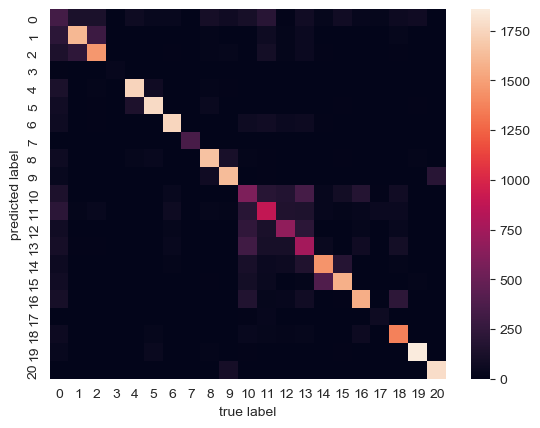

In [5]:
class_0_number = 2000
grid = train(model_name,result_train, label_train,number=2000) # 在均衡样本上进行训练
val(grid, result_val, label_val,number=2000)  # 在均衡的部分样本上测试
out_data = test(grid,result_test, label_test) # 在全部数据上进行测试，输出结果图  #没有加平衡D

In [6]:
label_test1 = label_test.reshape((5645376))
label_test2 = label_test1[label_test1!=0]
out_data2 = out_data[label_test1!=0]
print('支持向量机分类准确率：',accuracy_score(out_data2, label_test2)*100)


支持向量机分类准确率： 69.59620416488022


In [7]:
import cv2
label_paths = r'D:\gw\mae-main\data\SVM_data\text\label\labeal.png'
result_paths = r'D:\gw\mae-main\demo\result1000.png'
result = np.array(cv2.imread(result_paths, cv2.IMREAD_GRAYSCALE))
labels =  np.array(cv2.imread(label_paths, cv2.IMREAD_GRAYSCALE))
labels = labels[:1188,:4752]
result[labels==0] = 0

cv2.imwrite('result_ch.tif', result)

True

In [8]:
from sklearn.metrics import confusion_matrix, pairwise, hamming_loss
from tqdm.notebook import tqdm
disagreement = lambda a, b: np.sum(a != b) / len(a)
# 定义一个函数，计算两个混淆矩阵之间的欧几里得距离
def euclidean_distance(cm1, cm2):
    # cm1和cm2是两个相同大小的混淆矩阵
    # 初始化累加值为0
    sum_vals = 0
    # 遍历每个元素
    difference = cm1 - cm2
    sum_vals = difference*difference
    # for i in range(len(cm1)):
    #     for j in range(len(cm1[i])):
    #         # 计算每个元素之间的差异，并平方，然后累加
    #         sum_vals += (cm1[i][j] - cm2[i][j]) ** 2
    # 返回平方根值
    return sum_vals.sum() ** 0.5


def Difference_degree_comparison(results):
    # 初始化一个空列表，用于存储不同组合之间的差异度
    fits = []
    combs = []
    result, label = getimg(loaders="train", number = 54*54, addfeature=addfeature, model_name=model_name)  # 用深度学习网络获得特征
    X_train, y_train = aligned_sample(result, label, number=500,addfeature=addfeature) # 对每个类别分别进行2000次采样 ,并且打乱顺序
    result, label = getimg(loaders="val", number = 54*54, addfeature=addfeature, model_name=model_name,position_offset=54*54)  # 用深度学习网络获得特征
    X_test, y_test = aligned_sample(result, label, number=500,addfeature=addfeature) # 对每个类别分别进行2000次采样 ,并且打乱顺序
    # 用一个双重循环来遍历不同的支持向量机组合
    for i in tqdm(range(len(results['params']))):
        for j in range(len(results['params'])):
            if i==j:
                continue
            # 获取当前组合的两个分类器
            params = results['params'][i]
            clf_i = grid.best_estimator_ # 获取网格搜索的最佳管道对象
            clf_i.set_params(**params)# 修改管道对象中分类器的参数
            clf_i.fit(X_train, y_train)  # 训练分类器
            y_pred_i = clf_i.predict(X_test)  # 对测试集进行预测
            cm_i = confusion_matrix(y_test, y_pred_i)  # 分别计算分类器的混淆矩阵


            params = results['params'][j]
            clf_j = grid.best_estimator_ # 获取网格搜索的最佳管道对象
            clf_j.set_params(**params)# 修改管道对象中分类器的参数
            clf_j.fit(X_train, y_train)
            y_pred_j = clf_j.predict(X_test)
            acc_m = (accuracy_score(y_test, y_pred_i) + accuracy_score(y_test, y_pred_j))/2
            cm_j = confusion_matrix(y_test, y_pred_j)

            # 计算两个分类器之间的差异度和欧几里得距离
            difference = disagreement(y_pred_i,y_pred_j)
            diff_cm = euclidean_distance(cm_i, cm_j)
            # print(difference, diff_cm)
            # 将当前组合的分类器名称和差异度添加到列表中
            fits.append(difference*diff_cm * acc_m)
            combs.append([i, j])
            # 按照差异度的总和从大到小排序列表
            # fits.sort(key=lambda x: sum(x[1:]), reverse=False)
    return fits, combs , results['mean_test_score']

def filtrate_SVM(grid,top_number=2):
    """
    首先，计算每个SVM分类器的准确率，熵和差异度。准确率可以用accuracy_score函数来计算，熵可以用entropy函数来计算，差异度可以用disagreement函数来计算。这些函数都可以在sklearn.metrics模块中找到。
    然后，两两组合每个SVM分类器，并计算每个组合的合适度。合适度可以用你给出的公式来计算，即fit = (Disagreement + Entropy) * acc_m，其中acc_m是两个SVM分类器的平均准确率。
    接着，从所有的组合中，取合适度前10%的组合。你可以用np.argsort函数来对合适度进行排序，并取出前10%的索引。
    最后，对选出来的组合中的SVM分类器的准确率进行排名，并取前n^2 * 5%个。你可以用np.unique函数来去除重复的SVM分类器，并用np.sort函数来对准确率进行排序，并取出前n^2 * 5%个。
    """
    # 假设你已经得到了n个SVM分类器的列表svms
    Results = grid.cv_results_
    # 合适度的序列表
    fits, combs, accs= Difference_degree_comparison(grid.cv_results_)

    # 从所有的组合中，取合适度前10%的组合
    top_10 = int(len(fits) * 0.1)
    top_idx = np.argsort(fits)[-top_10:]
    top_combs = [combs[i] for i in top_idx]

    # 对选出来的组合中的SVM分类器的准确率进行排名，并取前n^2 * 5%个
    top_svms = []
    for comb in top_combs:
        top_svms.extend([comb[0], comb[1]])
    top_svms = np.unique(top_svms) # 去除重复

    top_accs = [accs[svm] for svm in top_svms]  # 获取支持向量机的准确率排名，找到最高的几个
    top_50 = top_number
    top_idx = np.argsort(top_accs)[-top_50:]
    final_svms = [top_svms[i] for i in top_idx]

    # 打印最终筛选出来的SVM分类器

    print(final_svms)
    return top_svms, final_svms
all_svms, final_svms = filtrate_SVM(grid, top_number=3)



[2, 0, 3]


In [9]:
accs = results['mean_test_score']

top_accs = [accs[svm] for svm in all_svms]  # 获取支持向量机的准确率排名，找到最高的几个
top_50 = 3
top_idx = np.argsort(top_accs)[-top_50:]
final_svms = [all_svms[i] for i in top_idx]
top_accs,all_svms, top_idx,final_svms

NameError: name 'results' is not defined

In [ ]:
all_svms, final_svms
results

In [ ]:
X, Y = aligned_sample(result_train, label_train, addfeature=addfeature, number=1000) # 对每个类别分别进行2000次采样 ,并且打乱顺序
X_val, Y_val = aligned_sample(result_val, label_val, addfeature=addfeature, number=1000) # 对每个类别分别进行2000次采样 ,并且打乱顺序

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.svm import SVC
# 获取网格搜索的结果字典
results = grid.cv_results_
# 定义多个支持向量机模型，使用不同的核函数和惩罚系数
models = list()
SVM = results['params']
for i,svm_idx in enumerate(final_svms):
    svm = SVM[svm_idx]
    print(svm_idx,svm)
    # 用字典推导式创建一个新的字典，只保留键名中不含'svc__'的键值对
    params = {k.replace('svc__', ''): v for k, v in svm.items() if 'svc__' in k}
    models.append((f'svm{i}', SVC(**params,probability=True,class_weight='balanced',kernel='rbf')))#

# 定义一个软投票法的集成模型
voting_clf = VotingClassifier(estimators=models, voting='soft')

print("训练集采样后",X.shape, Y.shape)
# 使用交叉验证评估集成模型的准确率，并添加error_score参数
# svm1.fit(X,Y)
# scores_svm1 = accuracy_score(svm1.predict(X), Y)
voting_clf.fit(X, Y)
y_pred = voting_clf.predict(X_val)
print(accuracy_score(y_pred, Y_val))